
<h1 align="center"> Statistics and Financial Data Analysis
<h1 align="center"> Examples


In [1]:
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import math
import scipy as sp
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm

In [2]:
df = pd.read_csv('nelsonplosser.csv')
df.tail()

,X.Y.m.d,gnp.r,gnp.n,gnp.pc,ip,emp,ur,gnp.p,cpi,wg.n,wg.r,M,vel,bnd,sp
106,19661231,658.1,749857.0,3349.0,98.0,76018.0,3.8,113.9,97.2,6643.0,68.34,308.0,1.76,4.75,85.26
107,19671231,675.2,793927.0,3399.0,100.0,77818.0,3.8,117.6,100.0,6880.0,68.80,331.8,1.72,4.95,91.93
108,19681231,706.6,864202.0,3522.0,105.8,79455.0,3.6,122.3,104.2,7347.0,70.51,361.6,1.72,5.93,98.70
109,19691231,724.7,929095.0,3577.0,110.7,81408.0,3.5,128.2,109.8,7775.0,70.81,385.2,1.73,6.54,97.84
110,19701231,720.0,974126.0,3516.0,106.7,81815.0,4.9,135.3,116.3,8150.0,70.08,401.3,1.73,7.60,83.82


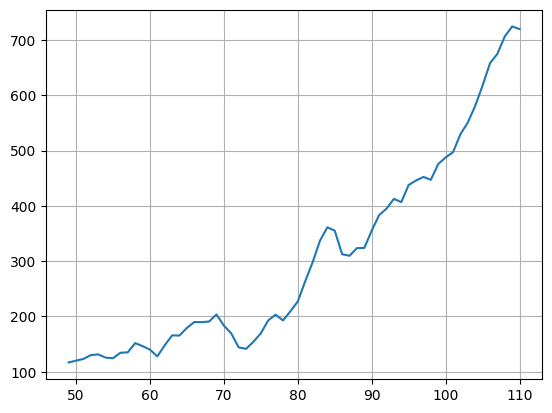

In [3]:
df['gnp.r'].dropna().plot()
plt.grid()

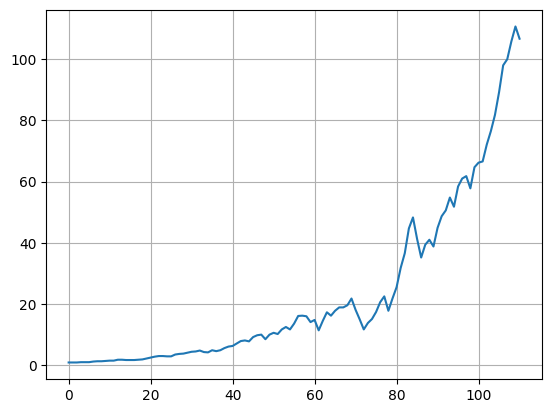

In [4]:
df['ip'].dropna().plot()
plt.grid()

In [5]:
x1 = df['gnp.r'].diff().dropna()
x2 = df['gnp.pc'].diff().dropna()
x3 = np.log(df['ip']).diff().dropna()
x4 = np.log(df['cpi']).diff().dropna()
x5 = df['emp'].diff().dropna()
x6 = df['bnd'].diff().dropna()
y = np.log(df['sp']).diff().dropna()

In [6]:
names = ['log_sp_diff','gnp_r_diff','gnp_pc_diff','log_ip_diff','log_cpi_diff','emp_diff','bnd_diff']
fullList = [y,x1, x2,x3,x4,x5,x6]
myDict = dict(zip(names, fullList))
df_np0 = pd.DataFrame({ key:pd.Series(value) for key, value in myDict.items()})
df_np = df_np0.dropna()

In [7]:
df_np.head()

,log_sp_diff,gnp_r_diff,gnp_pc_diff,log_ip_diff,log_cpi_diff,emp_diff,bnd_diff
50,-0.037780,3.3,9.0,0.058269,0.035091,690.0,0.03
51,-0.011834,3.1,12.0,-0.038466,0.000000,417.0,0.10
52,0.030903,7.0,54.0,0.137201,0.033902,1254.0,0.00
53,-0.113203,1.2,-15.0,0.066140,-0.010050,865.0,0.10
54,-0.051850,-5.8,-84.0,-0.066140,0.013378,-739.0,0.10


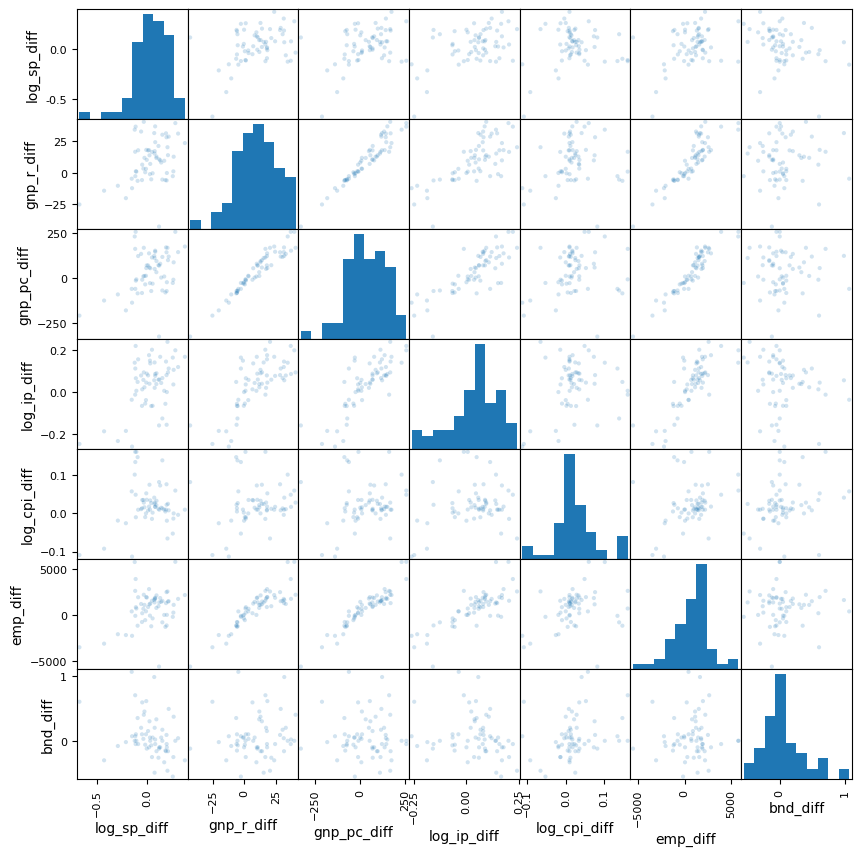

In [8]:
pd.plotting.scatter_matrix(df_np, alpha = 0.2, figsize= (10,10), );

In [9]:
X = df_np[['gnp_r_diff','gnp_pc_diff','log_ip_diff','log_cpi_diff','emp_diff','bnd_diff']]
y = df_np['log_sp_diff']

Xnew = sm.add_constant(X)
model_np = sm.OLS(y, Xnew).fit()
y_fitted = model_np.predict(Xnew)
model_np.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_sp_diff   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     5.167
Date:                Sun, 02 Oct 2022   Prob (F-statistic):           0.000293
Time:                        13:28:53   Log-Likelihood:                 32.904
No. Observations:                  61   AIC:                            -51.81
Df Residuals:                      54   BIC:                            -37.03
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0277      0.031     -0.882      0.381      -0.091       0.035
gnp_r_diff       0.0084      0.005      1.821      0.074      -0.001       0.018
gnp_pc_diff     -0.0010      0.001     -1.028      0.309      -0.003       0.001
log_ip_diff      0.6245      0.300      2.085      0.042       0.024       1.225
log_cpi_diff     0.4935      0.402      1.229      0.225      -0.312       1.299
emp_diff     -9.591e-06   3.35e-05     -0.287      0.776   -7.67e-05    5.75e-05
bnd_diff        -0.2030      0.074     -2.745      0.008      -0.351      -0.055
==============================================================================
Omnibus:                        1.405   Durbin-Watson:                   1.443
Prob(Omnibus):                  0.495   Jarque-Bera (JB):                1.253
Skew:                          -0.344   Prob(JB):                        0.534
Kurtosis:                       2.857   Cond. No.                     4.34e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.34e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

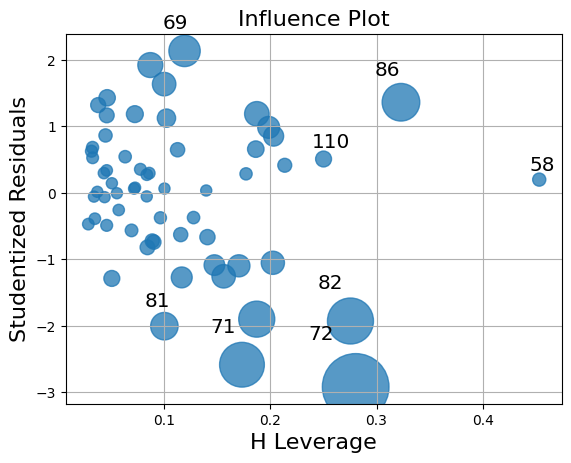

In [10]:
sm.graphics.influence_plot(model_np)
plt.grid()
#plt.savefig('influence')

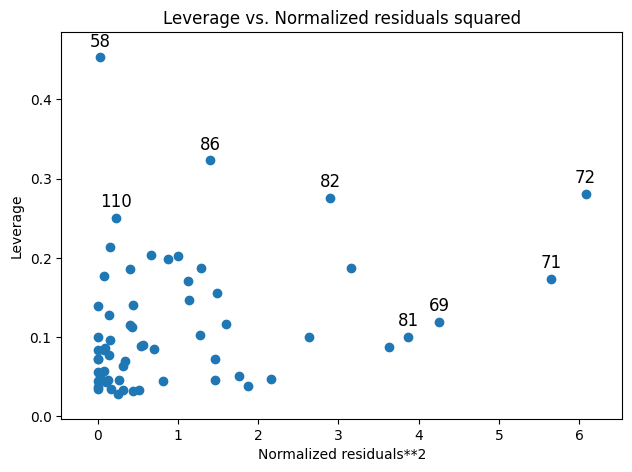

In [11]:
fig = sm.graphics.plot_leverage_resid2(model_np)
fig.tight_layout(pad=1.0)

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(df_np.values, i) for i in range(df_np.shape[1])]
vif["predictors"] = df_np.columns
vif

,VIF Factor,predictors
0,1.613520,log_sp_diff
1,11.061836,gnp_r_diff
2,21.428547,gnp_pc_diff
3,3.929561,log_ip_diff
4,1.480207,log_cpi_diff
5,11.994097,emp_diff
6,1.643292,bnd_diff


In [13]:
x1 = df['gnp.r'].diff().dropna()
x2 = df['gnp.pc'].diff().dropna()
x3 = df['ip'].diff().dropna()
x4 = df['cpi'].diff().dropna()
x5 = df['emp'].diff().dropna()
x6 = df['bnd'].diff().dropna()


names = ['gnpr','gnppc','ip','cpi','emp','bnd']
fullList = [x1, x2,x3,x4,x5,x6]
myDict = dict(zip(names, fullList))
df_x0 = pd.DataFrame({ key:pd.Series(value) for key, value in myDict.items()})
df_x = df_x0.dropna()

Text(0, 0.5, 'log diff ip')

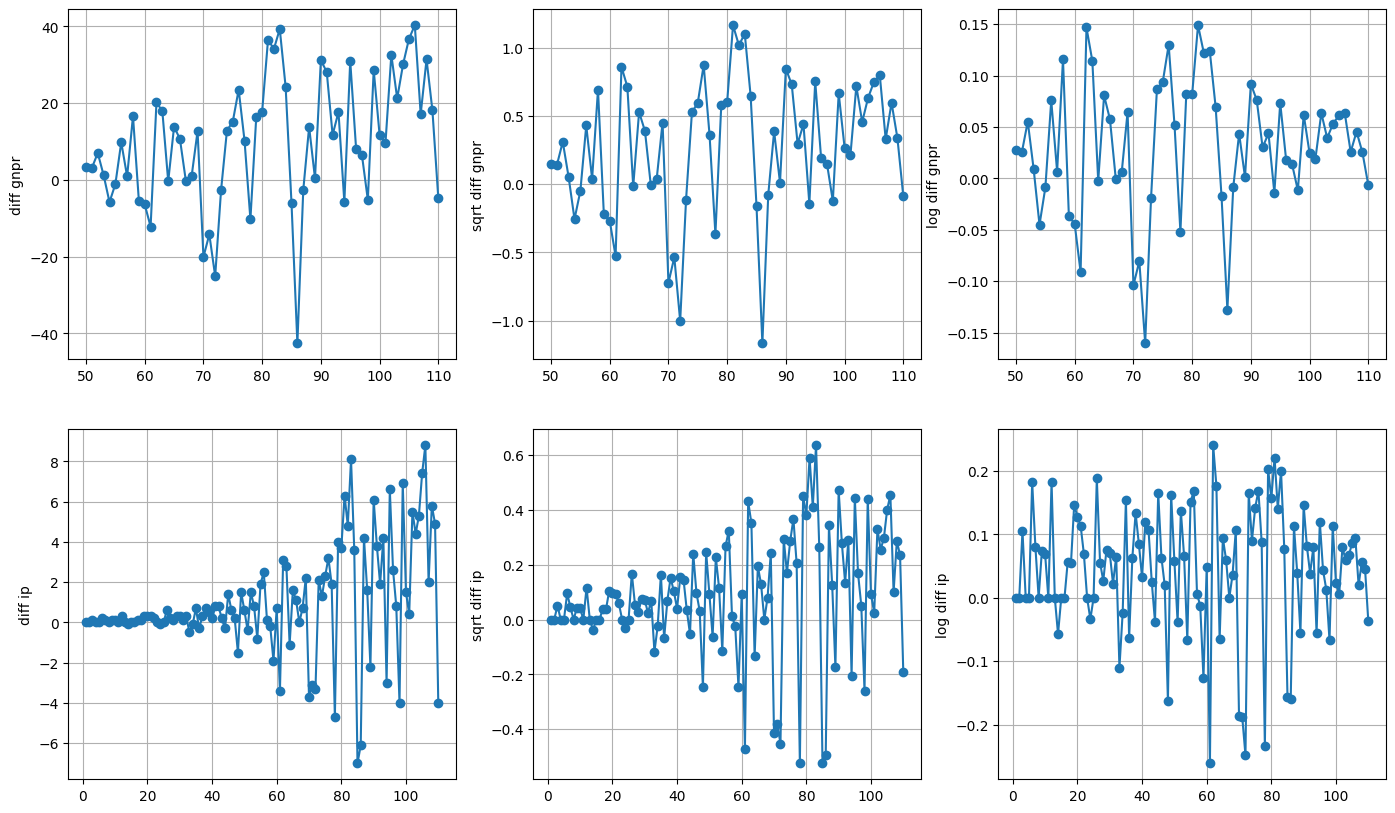

In [14]:
x1a = df['gnp.r'].diff().dropna()
x1b = np.sqrt(df['gnp.r']).diff().dropna()
x1c = np.log(df['gnp.r']).diff().dropna()

x3a = df['ip'].diff().dropna()
x3b = np.sqrt(df['ip']).diff().dropna()
x3c = np.log(df['ip']).diff().dropna()

plt.figure(figsize=(17,10))

plt.subplot(2,3, 1)
plt.plot(x1a,marker = 'o')
plt.grid()
plt.ylabel('diff gnpr')

plt.subplot(2,3, 2)
plt.plot(x1b,marker = 'o')
plt.grid()
plt.ylabel('sqrt diff gnpr')

plt.subplot(2,3, 3)
plt.plot(x1c,marker = 'o')
plt.grid()
plt.ylabel('log diff gnpr')

plt.subplot(2,3, 4)
plt.plot(x3a,marker = 'o')
plt.grid()
plt.ylabel('diff ip')

plt.subplot(2,3, 5)
plt.plot(x3b,marker = 'o')
plt.grid()
plt.ylabel('sqrt diff ip')

plt.subplot(2,3, 6)
plt.plot(x3c,marker = 'o')
plt.grid()
plt.ylabel('log diff ip')

#plt.savefig("NP_plots")


In [15]:
X = df_np[['log_ip_diff','bnd_diff']]
y = df_np['log_sp_diff']

Xnew = sm.add_constant(X)
model_np_2 = sm.OLS(y, Xnew).fit()
y_fitted_2 = model_np_2.predict(Xnew)
model_np_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            log_sp_diff   R-squared:                       0.309
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     12.95
Date:                Sun, 02 Oct 2022   Prob (F-statistic):           2.24e-05
Time:                        13:28:54   Log-Likelihood:                 30.326
No. Observations:                  61   AIC:                            -54.65
Df Residuals:                      58   BIC:                            -48.32
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0166      0.021      0.789      0.433      -0.025       0.059
log_ip_diff     0.6975      0.168      4.143      0.000       0.361       1.034
bnd_diff       -0.1322      0.062     -2.124      0.038      -0.257      -0.008
==============================================================================
Omnibus:                        4.023   Durbin-Watson:                   1.311
Prob(Omnibus):                  0.134   Jarque-Bera (JB):                3.176
Skew:                          -0.534   Prob(JB):                        0.204
Kurtosis:                       3.327   Cond. No.                         8.77
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0.5, 1.0, 'QQ Plot')

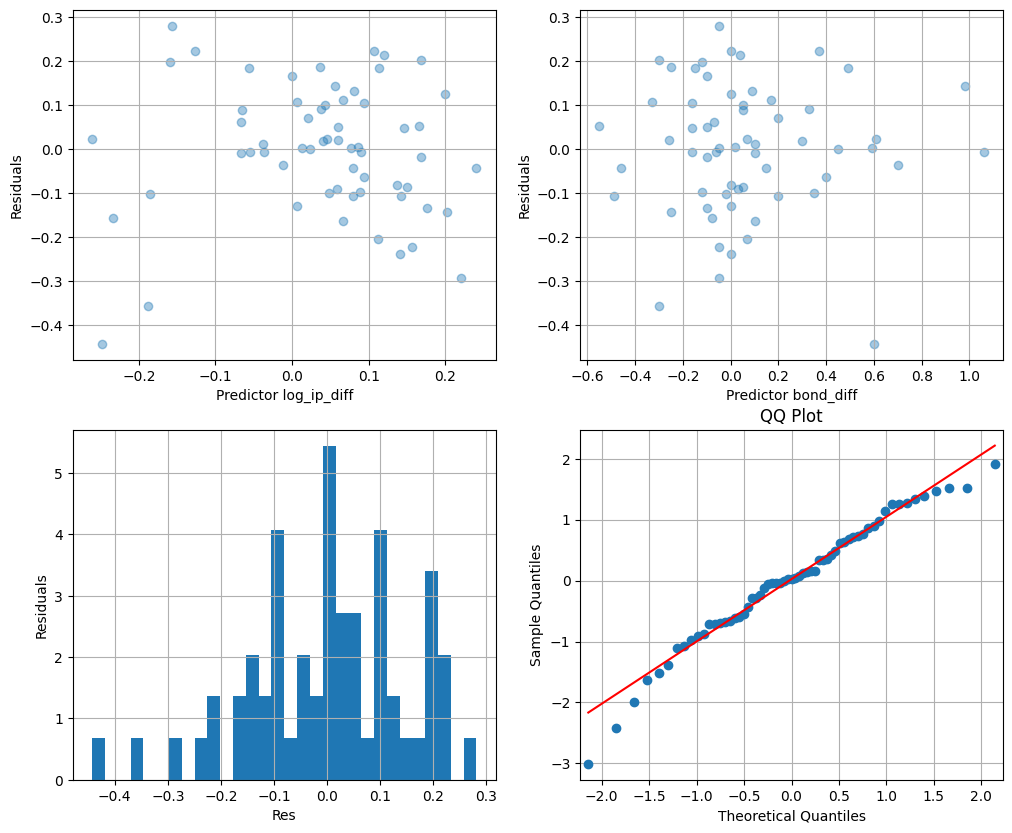

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,10))
ax= axes.flatten()

#fig.suptitle("A few diagnostic plots", size = 15)
res_np_2 = model_np_2.resid

ax[0].scatter(df_np['log_ip_diff'], res_np_2, marker = 'o', alpha = 0.4)
ax[0].grid()
ax[0].set(xlabel = 'Predictor log_ip_diff', ylabel = 'Residuals')

ax[1].scatter(df_np['bnd_diff'], res_np_2, marker = 'o', alpha = 0.4)
ax[1].grid()  
ax[1].set(xlabel = 'Predictor bond_diff', ylabel = 'Residuals')


ax[2].hist(res_np_2, bins = 30, density = True)
ax[2].grid()
ax[2].set(xlabel = 'Res', ylabel = 'Residuals')


sm.qqplot(res_np_2, fit = True, line='q',ax = ax[3])
ax[3].grid()
ax[3].set_title("QQ Plot")

#plt.savefig("Diagnostics_graphs1")